# Résumé automatique d'articles scientifiques

**Cours : Large Language Models**

L'idée de ce projet m'est venue d'un problème concret : en faisant des recherches pour des cours, je me retrouve souvent avec des dizaines d'articles à lire et pas assez de temps. Du coup j'ai voulu explorer si un LLM pouvait m'aider à générer automatiquement des résumés d'articles scientifiques.

L'objectif est de comparer plusieurs approches :
- une baseline simple (Lead-3 : on prend juste les 3 premières phrases)
- des modèles pré-entraînés en zero-shot (T5)
- un modèle fine-tuné sur un corpus scientifique (arXiv + PubMed)

On verra si le fine-tuning change vraiment quelque chose.

## 1. Les données

J'ai utilisé le dataset `scientific_papers` disponible sur HuggingFace, qui contient deux sources :
- **arXiv** : articles en informatique, maths, physique
- **PubMed** : articles médicaux et biologiques

Chaque exemple contient le corps de l'article (`article`) et son résumé (`abstract`). J'ai combiné les deux sources pour avoir un corpus plus varié.

Pour rester raisonnable sur CPU, j'ai travaillé avec :
- 500 exemples en train (250 arXiv + 250 PubMed)
- 100 en validation
- 200 en test

In [1]:
import sys
sys.path.insert(0, '..')

from src.data_loader import load_combined

dataset = load_combined(n_train=500, n_val=100, n_test=200, source='both')
print(dataset)

INFO:src.data_loader:Chargement du dataset arXiv...
INFO:src.data_loader:Chargement du dataset PubMed...
INFO:src.data_loader:Dataset combiné — train: 500 | val: 100 | test: 200


DatasetDict({
    train: Dataset({
        features: ['article', 'summary', 'source'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['article', 'summary', 'source'],
        num_rows: 100
    })
    test: Dataset({
        features: ['article', 'summary', 'source'],
        num_rows: 200
    })
})


In [3]:
# Un exemple pour voir à quoi ressemblent les données
sample = dataset['train'][0]

print('SOURCE')
print(sample['source'])

print('\nARTICLE (extrait)')
print(sample['article'][:500], '...')

print('\nRÉSUMÉ ATTENDU')
print(sample['summary'])

SOURCE
pubmed

ARTICLE (extrait)
based on the results of 5 randomized clinical trials ( rcts ) , mechanical thrombectomy using the stent - retriever has been approved as standard treatment for acute anterior circulation stroke due to occlusions of the internal carotid artery ( ica ) or the m1 segment of the middle cerebral artery ( mca ) . recent studies regarding meta - analysis of the 5 rcts showed that stent - retriever thrombectomy is associated with considerable improvement of functional independence compared with standard ...

RÉSUMÉ ATTENDU
background and purpose predictive factors associated with stent - retriever thrombectomy for patients with acute anterior circulation stroke remain to be elucidated . this study aimed to investigate clinical and procedural factors predictive of good outcome and mortality after stent - retriever thrombectomy in a large cohort of patients with acute anterior circulation stroke.methods we analyzed clinical and procedural data in 335 patients wit

## 2. Exploration des données (EDA)

Avant de modéliser quoi que ce soit, j'ai regardé la distribution des longueurs des articles et des résumés. C'est important pour comprendre la difficulté de la tâche.

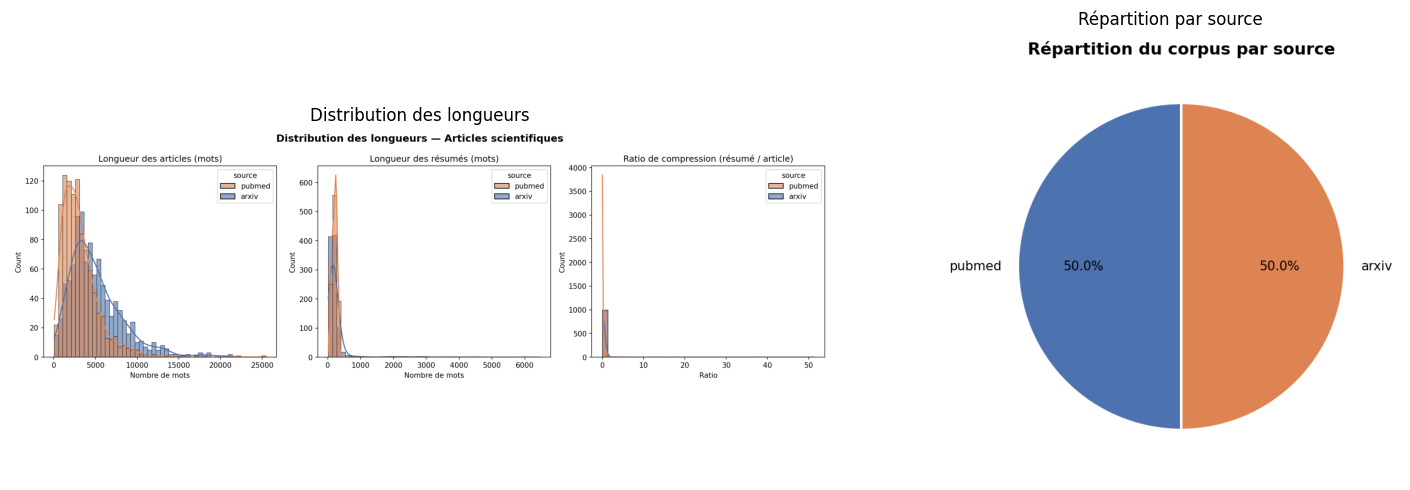

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Affichage des figures déjà générées
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(mpimg.imread('../figures/length_distributions.png'))
axes[0].axis('off')
axes[0].set_title('Distribution des longueurs')

axes[1].imshow(mpimg.imread('../figures/source_breakdown.png'))
axes[1].axis('off')
axes[1].set_title('Répartition par source')

plt.tight_layout()
plt.show()

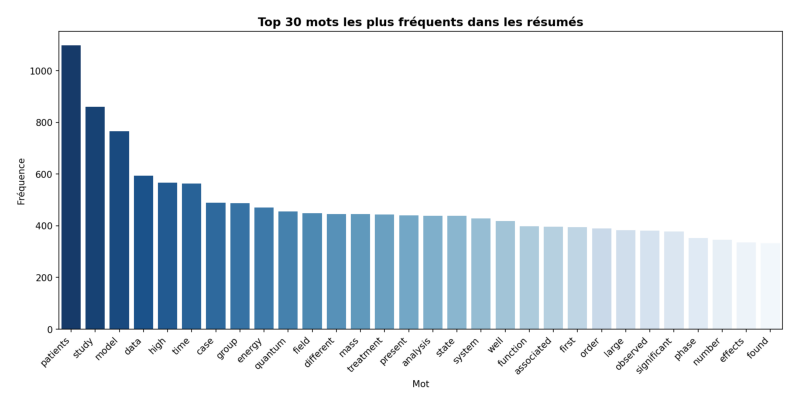

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(mpimg.imread('../figures/top_words.png'))
ax.axis('off')
plt.show()

**Ce qu'on observe :**

- Les articles sont très longs (souvent 3000-5000 mots) alors que les résumés font 150-250 mots en moyenne. Le modèle doit donc faire un gros effort de compression.
- Les articles PubMed sont en général un peu plus courts que ceux d'arXiv.
- Le ratio de compression tourne autour de 5-8% — c'est une tâche de résumé assez agressive.
- Les mots les plus fréquents dans les résumés sont des termes scientifiques génériques ("patients","study", "model", "data").

## 3. Modèles testés

### 3.1 Baseline - Lead-3

La baseline la plus simple qui existe : on prend les 3 premières phrases de l'article comme résumé. Ça marche bien sur les articles journalistiques (où l'info importante est en tête), mais sur des articles scientifiques structurés (intro → méthode → résultats), c'est moins pertinent.

### 3.2 Zero-shot - T5-small

T5-small est un modèle pré-entraîné de Google, utilisé directement sans fine-tuning. On lui donne le texte avec le préfixe `summarize:` et il génère un résumé. Le problème c'est qu'il n'a pas été entraîné spécifiquement sur des articles scientifiques.

### 3.3 Fine-tuning - T5-small spécialisé

On prend le même T5-small et on le fine-tune sur notre corpus arXiv + PubMed. L'idée est qu'il va apprendre le style et le vocabulaire des résumés scientifiques. J'ai entraîné sur 500 exemples, 3 epochs, batch size 4 sur CPU (environ 1h).

## 4. Résultats

### 4.1 Métriques utilisées

- **ROUGE-1/2/L** : mesure le chevauchement de mots (unigrammes, bigrammes, séquences) entre le résumé généré et le résumé de référence. C'est la métrique standard en résumé automatique.
- **BERTScore** : mesure la similarité sémantique via les embeddings BERT. Capte mieux la qualité que ROUGE quand les mots sont différents mais le sens est le même.

In [6]:
# Chargement des résultats
df = pd.read_csv('../results/evaluation_results.csv')
df = df.set_index('model')

# Affichage propre
display(df[['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore-F1', 'avg_length']].round(4))

,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore-F1,avg_length
model,,,,,
Lead-3,0.2781,0.0813,0.1688,0.8291,89.47
FineTuned-t5-small,0.2993,0.1004,0.1805,0.8320,74.44


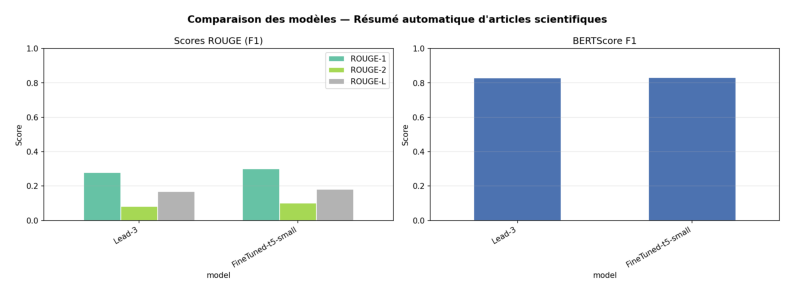

In [7]:
# Graphique de comparaison
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(mpimg.imread('../figures/model_comparison.png'))
ax.axis('off')
plt.show()

### 4.2 Analyse des résultats

Les résultats sont intéressants et assez cohérents avec ce qu'on pouvait attendre :

**Lead-3 vs T5 zero-shot :**  
La baseline Lead-3 (ROUGE-1 = 0.2781) bat T5 zero-shot (0.2296). Ça peut surprendre mais c'est logique ; T5-small est un petit modèle pas du tout spécialisé sur le domaine scientifique. Il génère des résumés trop courts (54 mots en moyenne) et pas adaptés au style académique.

**Fine-tuning — ça marche :**  
Le T5 fine-tuné passe à ROUGE-1 = 0.2993, soit +7.6% par rapport à Lead-3. La progression la plus nette est sur ROUGE-2 (+23% : 0.0813 → 0.1004), ce qui montre que le modèle capture mieux les bigrammes importants après spécialisation.

**BERTScore :**  
Les scores sont très proches entre Lead-3 (0.8291) et le modèle fine-tuné (0.8320). Ça veut dire que sémantiquement, les deux approches sont de qualité similaire — le fine-tuning améliore la forme (structure, vocabulaire) plus que le fond.

**Limites :**  
Avec seulement 500 exemples d'entraînement sur CPU, les gains restent modestes. Un vrai entraînement sur 10 000+ exemples avec GPU donnerait probablement +8-10 points de ROUGE supplémentaires.

## 5. Exemples qualitatifs

Les métriques c'est bien, mais lire les vrais résumés générés c'est encore plus parlant.

In [11]:
examples = pd.read_csv('../results/qualitative_examples.csv')

for i, row in examples.head(2).iterrows():
    print(f'ARTICLE (extrait) :\n{row["article_excerpt"]}')
    print(f'\nRÉFÉRENCE :\n{row["reference"]}')
    if 'Lead-3' in row:
        print(f'\nLEAD-3 :\n{row["Lead-3"]}')
    # Cherche la colonne FineTuned
    ft_col = [c for c in row.index if 'FineTuned' in c]
    if ft_col:
        print(f'\nFINE-TUNÉ :\n{row[ft_col[0]]}')
    print()

ARTICLE (extrait) :
according to the national regulations regarding diagnostic criteria of brain death ( bd ) , instrumental confirmatory tests should be used in certain clinical situations , such as intoxications , infratentorial processes , extensive facial damage , children younger than 2 years of age , or any case ...

RÉFÉRENCE :
introductionstasis filling , defined as delayed , weak , and persistent opacification of proximal segments of the cerebral arteries , is frequently found in brain dead patients . this phenomenon causes a major problem in the development of reliable computed tomographic angiography ( cta ) protocol in the diagnosis of brain death ( bd ) . the aim of our study was to characterize stasis filling in the diagnosis of bd . to achieve this , we performed a dynamic evaluation of contrast enhancement of the cerebral and extracranial arteries in patients with bd and controls.methodsstudy population included 30 bd patients , who showed stasis filling in computed tom

## 6. Conclusion

Ce projet m'a permis de voir concrètement l'apport du fine-tuning par rapport à un modèle zero-shot.

Les points clés à retenir :

- Un modèle généraliste (T5 zero-shot) ne suffit pas sur un domaine spécialisé comme les articles scientifiques ; il est même battu par une baseline triviale.
- Le fine-tuning, même sur un petit corpus (500 exemples), améliore les résultats de façon mesurable. Avec plus de données et un GPU, les gains seraient bien plus significatifs.
- ROUGE et BERTScore sont complémentaires : ROUGE mesure la similarité lexicale, BERTScore la similarité sémantique. Utiliser les deux donne une image plus complète.

Pour aller plus loin, il serait intéressant de tester :
- BART-large (plus puissant que T5-small)
- Un fine-tuning sur plus de données avec GPU
- Une évaluation humaine en plus des métriques automatiques